## Dataset

The dataset with test and train data is downloaded from [Kaggle's Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic/data)



## Importing Packages


In [14]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import seaborn as sns

import keras
from keras import layers

import random
import time

In [15]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

### Loading dataset

In [16]:
df = pd.read_csv("Data/titanic.csv")

In [17]:
print(f"Shape of dataset: {df.shape}")

Shape of dataset: (891, 12)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The features of the dataset:

| Variable | Definition | Key |
|---|---|---|
| survived | Survival | 0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd
| sex | Sex | |	
| Age | Age | in years |
| sibsp	| # of siblings / spouses aboard the Titanic | |	
| parch | # of parents / children aboard the Titanic | |
| ticket | Ticket number  | |
|fare | Passenger fare | |
|cabin | Cabin number | |
|embarked | Port of Embarkation	| C = Cherbourg, Q = Queenstown, S = Southampton|


## Preprocessing

In [23]:
print(f'value counts of {df.Survived.value_counts()}')

value counts of Survived
0    549
1    342
Name: count, dtype: int64


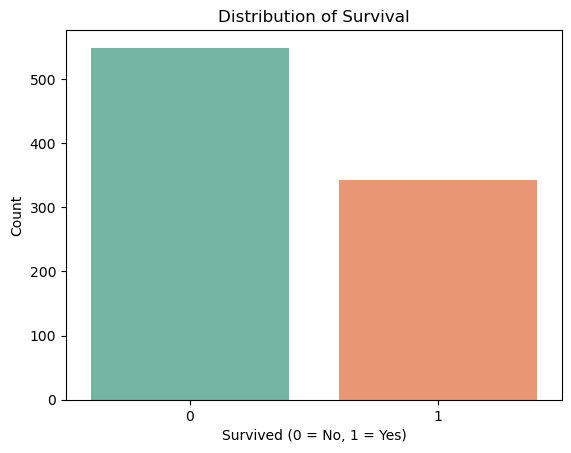

In [22]:
sns.countplot(x='Survived', data=df, palette='Set2', hue='Survived', legend=False)
plt.title('Distribution of Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [24]:
df.isnull().sum() / len(df) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

The features `Age`, `Cabin`, and `Embarked` have missing values. The percentage of missing values in `Cabin` is very high ($77.10$).